# Reconocimiento de Patrones

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from skimage.measure import label, regionprops_table
from skimage.morphology import skeletonize
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

2025-05-31 18:32:38.867850: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-31 18:32:38.868823: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-31 18:32:38.873411: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-31 18:32:38.883621: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748727158.899264   16083 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748727158.90

In [29]:
def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()
    
def show_images(images, titles=None):
    """Display multiple images in a grid."""
    n = len(images)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    for i in range(n):
        image = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)
        axes[i].imshow(image)
        if titles:
            axes[i].set_title(titles[i])
        axes[i].axis('off')
    
    for j in range(i + 1, rows * cols):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

>**1. (*) Template Matching. Buscar una figura conocida dentro de una imagen mediante una plantilla.
Sugerencia: cv2.matchTemplate, cv2.minMaxLoc.**

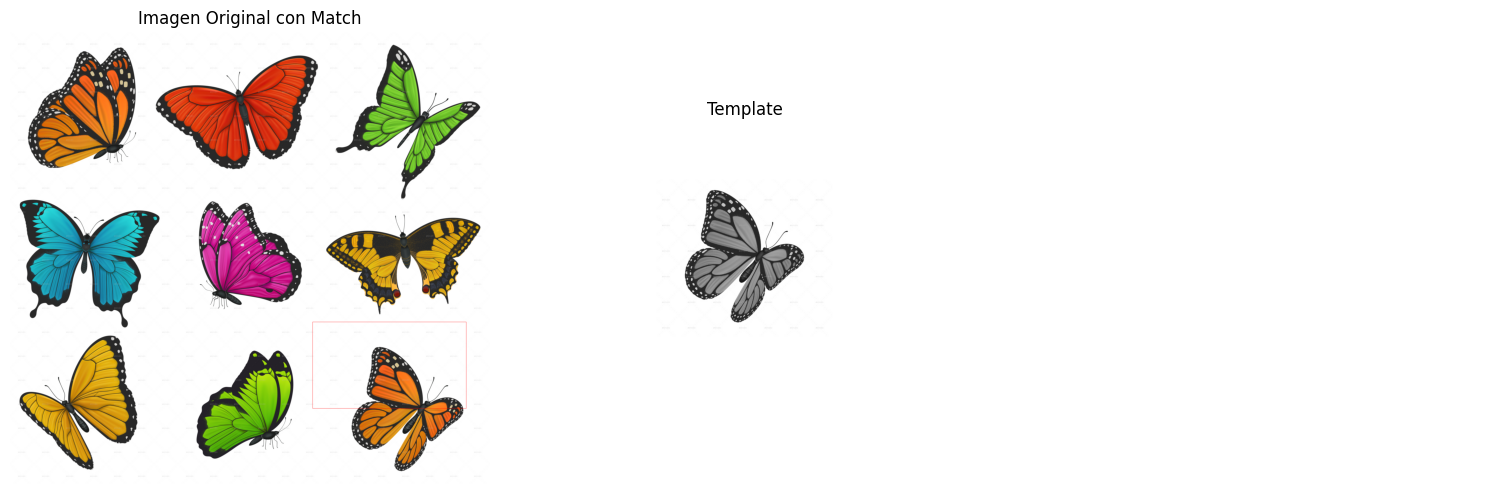

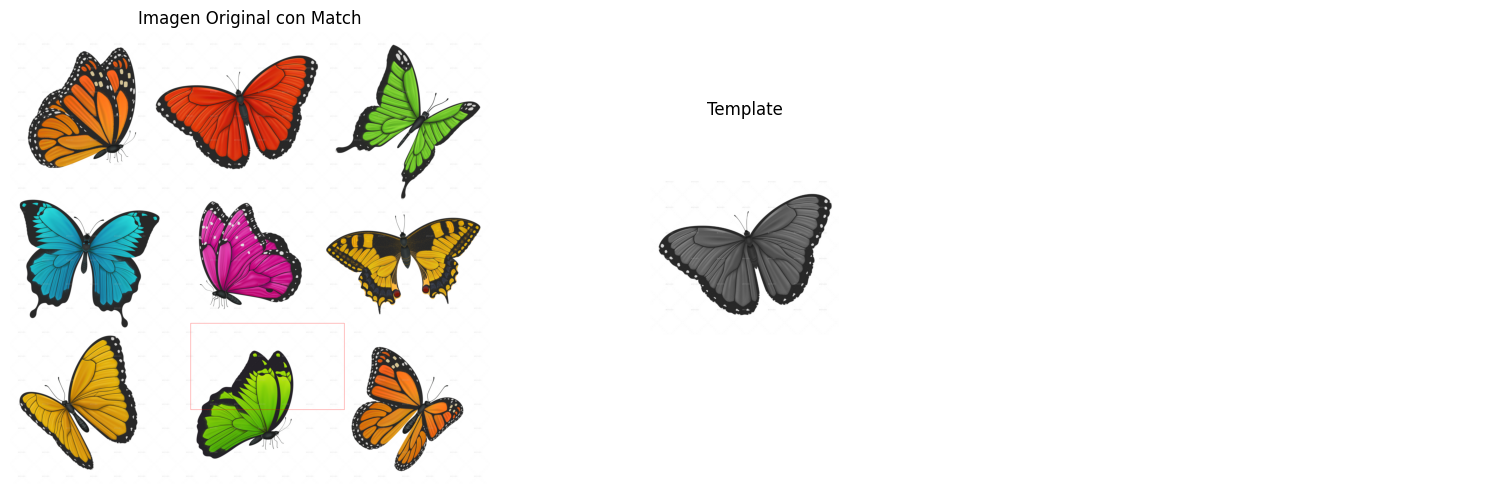

In [15]:

def ej1(img, template):

    image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Obtener dimensiones del template
    h, w = template.shape

    # Aplicar template matching
    result = cv2.matchTemplate(image, template, cv2.TM_CCOEFF_NORMED)

    # Encontrar el valor máximo y su ubicación
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    # Las coordenadas del mejor match
    top_left = max_loc
    bottom_right = (top_left[0] + w, top_left[1] + h)

    # Dibujar rectángulo en la imagen original (convertimos a color para visualizarlo)
    cv2.rectangle(image_color, top_left, bottom_right, (0, 0, 255), 2)

    # Mostrar imágenes
    show_images(
        [image_color, template],
        titles=['Imagen Original con Match', 'Template']
    )


image_color = cv2.imread('butterflies.jpg', cv2.IMREAD_COLOR)
template = cv2.imread('butterfly-plantilla.png', cv2.IMREAD_GRAYSCALE)

ej1(image_color, template)

# Repetimos el ejercicio con una segunda plantilla
image_color = cv2.imread('butterflies.jpg', cv2.IMREAD_COLOR)
template = cv2.imread('butterfly-plantilla2.png', cv2.IMREAD_GRAYSCALE)
ej1(image_color, template)


>**2. (*) Clasificación basada en características. Extraer características simples (como área o textura) de
regiones segmentadas y clasificarlas usando KNN. Sugerencia: scikit-learn + descriptores de regionprops.**

 Para este ejercicio se realiza la clasificación de figuras geométricas en una imagen. Primero, lee la imagen en escala de grises y luego invierte los colores para que las figuras sean blancas sobre fondo negro. Después aplica un umbral automático usando el método de Otsu para separar las figuras del fondo. Luego, etiqueta cada una de las regiones detectadas y extrae características geométricas como área, excentricidad y perímetro. A esas regiones se les asignan etiquetas manuales según su forma (círculo, triángulo o cuadrado), siguiendo el orden visual en que aparecen. Con esas características y etiquetas, se entrena un clasificador K-Nearest Neighbors (KNN). Los datos se escalan, se dividen en conjunto de entrenamiento y prueba, y finalmente se entrena el modelo y se evalúa su rendimiento imprimiendo un reporte de clasificación.

              precision    recall  f1-score   support

           0       0.30      1.00      0.46         3
           1       1.00      0.12      0.22         8
           2       0.71      0.71      0.71         7

    accuracy                           0.50        18
   macro avg       0.67      0.61      0.47        18
weighted avg       0.77      0.50      0.45        18



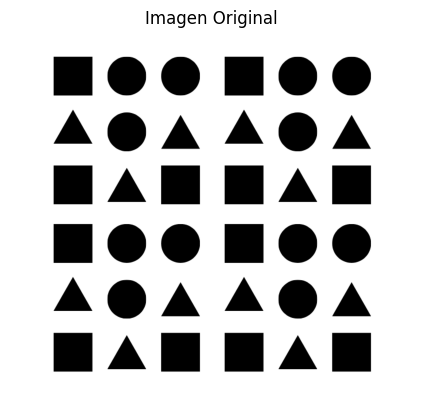

In [ ]:

# 1. Leer imagen en escala de grises
image = cv2.imread('shapes.png', cv2.IMREAD_GRAYSCALE)

# 2. Invertimos colores (blanco fondo -> negro fondo)
image_inv = cv2.bitwise_not(image)

# 3. Umbral binario + Otsu
_, thresh = cv2.threshold(image_inv, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Etiquetar regiones
labeled_image = label(thresh)

# 5. Extraer características
features = ['area', 'eccentricity', 'solidity', 'extent', 'perimeter']
props = regionprops_table(labeled_image, intensity_image=image_inv, properties=features)
df = pd.DataFrame(props)

# 6. Asignar etiquetas manuales
df['label'] =labels = [
    2, 0, 0, 2, 0, 0,
    1, 0, 1, 1, 0, 1,
    2, 1, 2, 2, 1, 2,
    2, 0, 0, 2, 0, 0,
    1, 0, 1, 1, 0, 1,
    2, 1, 2, 2, 1, 2
] # 0: círculo, 1: triángulo, 2: cuadrado

# 7. Clasificación con KNN
X = df[features]
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.5, random_state=42)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred))

show_image(image, title='Imagen Original')

>**5. (*) Reconocimiento estructural. Representar caracteres como grafos de líneas y nodos. Clasificarlos
según su estructura. Sugerencia: Estructuras de grafos con networkx (librería de python).**

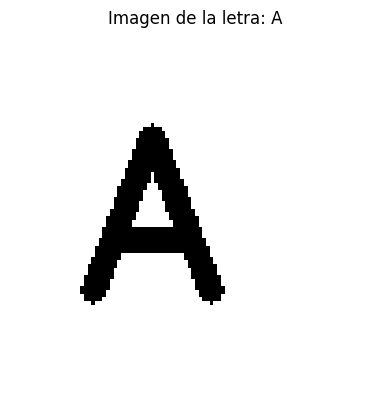

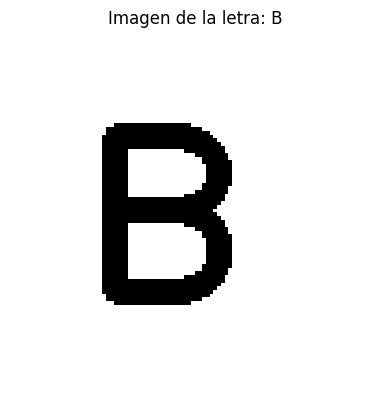

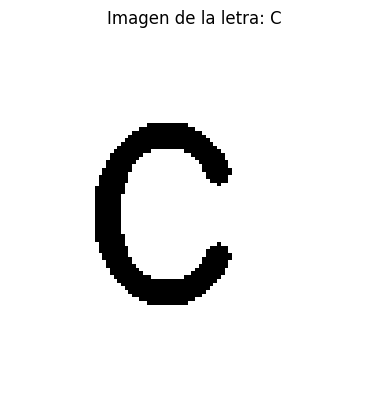

              precision    recall  f1-score   support

           0       0.33      1.00      0.50         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



/home/luciano/Documentos/Facultad/procesamiento-de-imagenes/TPs_PDI/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/luciano/Documentos/Facultad/procesamiento-de-imagenes/TPs_PDI/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/luciano/Documentos/Facultad/procesamiento-de-imagenes/TPs_PDI/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicte

In [40]:

# Función auxiliar: crea una imagen binaria con una letra
def create_char_image(letter):
    img = np.ones((100, 100), dtype=np.uint8) * 255
    cv2.putText(img, letter, (20, 70), cv2.FONT_HERSHEY_SIMPLEX, 2, (0), 5)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)

    show_image(img, title=f'Imagen de la letra: {letter}')

    return binary

def extract_graph_features(img):
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    skeleton = skeletonize(binary // 255)
    coords = np.argwhere(skeleton)
    G = nx.Graph()
    for y, x in coords:
        G.add_node((y, x))
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == dx == 0:
                    continue
                ny, nx_ = y + dy, x + dx
                if (ny, nx_) in G.nodes:
                    G.add_edge((y, x), (ny, nx_))
    
    # Extraer descriptores simples del grafo
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    endpoints = len([n for n in G.nodes if G.degree[n] == 1])
    junctions = len([n for n in G.nodes if G.degree[n] > 2])
    cycles = len(nx.cycle_basis(G))

    return [num_nodes, num_edges, endpoints, junctions, cycles]

# Crear dataset con letras y extraer features
letters = ['A', 'B', 'C']
X = []
y = []

exts = ['.png', '.jpg', '.jpeg']

for label, char in enumerate(letters):
    # Nombre del archivo en minusculas 
    char = char.lower()
    for i in range(1, 4):  # Hay 3 imágenes por letra: a1, a2, a3, etc.
        found = False
        for ext in exts:
            filename = f"{char}{i}{ext}"
            if os.path.isfile(filename):
                img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)                
                _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
                feats = extract_graph_features(binary)
                X.append(feats)
                y.append(label)
                found = True
                break
        if not found:
            print(f"Imagen no encontrada para: {char}{i} (probadas extensiones {exts})")


# Crear dataset de prueba con create_char_image()
X_test = []
y_test = []

for label, char in enumerate(letters):
    for i in range(1):  # 1 muestras por letra para test
        binary = create_char_image(char)
        feats = extract_graph_features(binary)
        X_test.append(feats)
        y_test.append(label)

# Clasificación con KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluación
print(classification_report(y_test, y_pred))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/home/luciano/Documentos/Facultad/procesamiento-de-imagenes/TPs_PDI/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-31 18:33:10.870842: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.8698 - loss: 0.4274 - val_accuracy: 0.9828 - val_loss: 0.0621
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9805 - loss: 0.0614 - val_accuracy: 0.9860 - val_loss: 0.0422
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9890 - loss: 0.0374 - val_accuracy: 0.9862 - val_loss: 0.0426
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9909 - loss: 0.0280 - val_accuracy: 0.9892 - val_loss: 0.0396
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.9938 - loss: 0.0211 - val_accuracy: 0.9887 - val_loss: 0.0383
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9861 - loss: 0.0434

Precisión en test: 0.9904


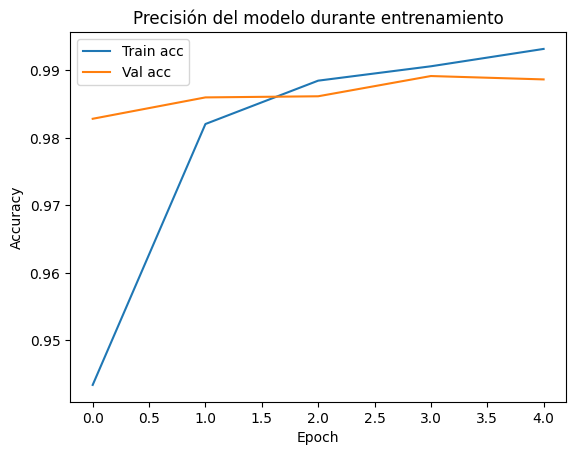

In [42]:
# 1. Cargar dataset MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocesamiento
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 3. Definir arquitectura CNN
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Compilar modelo
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 5. Entrenamiento
history = model.fit(x_train, y_train_cat, epochs=5, batch_size=64, validation_split=0.1)

# 6. Evaluación
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\nPrecisión en test: {test_acc:.4f}")

# 7. Visualizar métricas
plt.plot(history.history['accuracy'], label='Train acc')
plt.plot(history.history['val_accuracy'], label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Precisión del modelo durante entrenamiento')
plt.show()